In [272]:
import pandas as pd
import matplotlib.pyplot as plt

# Define color codes for colored print statements
class Colors:
    # Text colors
    RED = '\033[91m'
    GREEN = '\033[92m'
    
    # Text formatting
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    
    # Reset to normal
    RESET = '\033[0m'

def colored_print(text, color=Colors.RED, style=""):
    """Print colored text with optional styling"""
    print(f"{style}{color}{text}{Colors.RESET}")

df = pd.read_csv('data/TSLA.csv')

In [284]:
# Display the first few rows and basic info about your dataset
# Questions to answer:  
# - Display head of the DataFrame to verify it loaded correctly 
# - See the columns of the dataset

df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Month,Price Change,Year
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500,June,0.978,2010
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500,June,-0.392,2010
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000,July,-0.608,2010
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000,July,-0.760,2010
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500,July,-0.778,2010


## Question 1: High Volume Trading Days Analysis

**Task:** Find the top 10 days with the highest trading volume and analyze what happened to prices on those days.

**Skills demonstrated:**
- **SORTING**: Order data by volume
- **FILTERING**: Get top 10 results  
- **DATA CONVERSION**: Calculate price changes and percentages
- **AGGREGATION**: Compute averages

**Questions to answer:**
- What was the highest volume trading day?
- On high volume days, do prices usually go up or down?
- What's the average volume on these high-volume days?

In [274]:
# Question 1 - Find the top 10 days with the highest trading volume and analyze what happened to prices on those days.
print("Question 1 - Find the top 10 days with the highest trading volume and analyze what happened to prices on those days.")

# format the date to "Feb 2, 2025" format - M-D-YYYY
df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%b %#d, %Y')

# find the top 10 days
top_volume_days = df.nlargest(10, 'Volume')
top_volume_days['Price Change'] = top_volume_days['Close'] - top_volume_days['Open']
top_volume_days['Price Change %'] = ((top_volume_days['Price Change'] / top_volume_days['Open']) * 100).map(lambda x: f"{x:.2f}%")

# create a new dataframe to store the results and display it
analysis_df = top_volume_days[['Date', 'Volume', 'Price Change', 'Price Change %']]
analysis_df.reset_index(drop=True, inplace=True)
display(analysis_df)



# analyze the data and print insights
print("-" * 80)
print("Analyzation of the top 10 highest volume trade days:")
print()
print("-" * 80)
# ------------------------------------------
print("What is the highest volume trade day?")
highest_volume_day = top_volume_days.iloc[0]
print(f"Date: {highest_volume_day['Date']} With a volume of {highest_volume_day['Volume']:,} and a price change of {highest_volume_day['Price Change']:.2f} which is ({highest_volume_day['Price Change %']})")
# ------------------------------------------
print()
print("-" * 80)
print("What is the lowest volume trade day among the top 10?")
lowest_volume_day = top_volume_days.iloc[-1]
print(f"Date: {lowest_volume_day['Date']} With a volume of {lowest_volume_day['Volume']:,} and a price change of {lowest_volume_day['Price Change']:.2f} which is ({lowest_volume_day['Price Change %']})")
# ------------------------------------------
print()
print("-" * 80)
print("Do high volume days usually result in an increase or decrease in price?")
price_increase_count = (top_volume_days['Price Change'] > 0).sum()
price_decrease_count = (top_volume_days['Price Change'] < 0).sum()
if price_increase_count > price_decrease_count:
    print(f"Out of the top 10 highest volume days, {price_increase_count} resulted in a price increase while {price_decrease_count} \n resulted in a price decrease. High volume days tend to result in an increase in price.")
elif price_decrease_count > price_increase_count:
    print(f"Out of the top 10 highest volume days, {price_decrease_count} resulted in a price decrease while {price_increase_count} \n  resulted in a price increase. High volume days tend to result in a decrease in price.")
else:
    print(f"Out of the top 10 highest volume days, {price_increase_count} resulted in a price increase while {price_decrease_count} \n  resulted in a price decrease. High volume days do not show a clear tendency to result in either an increase or decrease in price.")
# ------------------------------------------
print()
print("-" * 80)
print("What is the average volume on the top 10 highest volume days?")
average_volume = top_volume_days['Volume'].mean()
print(f"The average volume on the top 10 highest volume days is {average_volume:,.0f}.")

# print summary statements
def print_summary_statements_volume():
    print("-" * 80)
    print("Question 1: Find the top 10 days with the highest trading volume and analyze what happened to prices on those days?")
    print("-" * 80)
    print("1. The highest volume trading day was on {} with a volume of {:,} and a price change of {:.2f} ({}).".format(highest_volume_day['Date'], highest_volume_day['Volume'], highest_volume_day['Price Change'], highest_volume_day['Price Change %']))
    print("2. The lowest volume trading day among the top 10 was on {} with a volume of {:,} and a price change of {:.2f} ({}).".format(lowest_volume_day['Date'], lowest_volume_day['Volume'], lowest_volume_day['Price Change'], lowest_volume_day['Price Change %']))          
    colored_print("This indicates that high volume days can lead to significant price changes,\n but the direction of the change (increase or decrease) is not consistent across all high volume days.", Colors.GREEN)

Question 1 - Find the top 10 days with the highest trading volume and analyze what happened to prices on those days.


,Date,Volume,Price Change,Price Change %
0,"Feb 4, 2020",304694000,0.820008,0.46%
1,"Feb 5, 2020",242119000,-17.711991,-10.76%
2,"Feb 3, 2020",235325000,21.261993,15.78%
3,"Dec 18, 2020",222126200,26.099976,3.90%
4,"Feb 6, 2020",199404000,9.808013,7.01%
5,"Jul 13, 2020",194927000,-32.388001,-9.76%
6,"May 14, 2013",185819500,-2.195999,-11.65%
7,"Sep 28, 2018",168248500,-1.097999,-2.03%
8,"Feb 25, 2014",163408500,3.599998,7.83%
9,"May 1, 2020",162659000,-10.735992,-7.11%


--------------------------------------------------------------------------------
Analyzation of the top 10 highest volume trade days:

--------------------------------------------------------------------------------
What is the highest volume trade day?
Date: Feb 4, 2020 With a volume of 304,694,000 and a price change of 0.82 which is (0.46%)

--------------------------------------------------------------------------------
What is the lowest volume trade day among the top 10?
Date: May 1, 2020 With a volume of 162,659,000 and a price change of -10.74 which is (-7.11%)

--------------------------------------------------------------------------------
Do high volume days usually result in an increase or decrease in price?
Out of the top 10 highest volume days, 5 resulted in a price increase while 5 
  resulted in a price decrease. High volume days do not show a clear tendency to result in either an increase or decrease in price.

-----------------------------------------------------------

## Question 2: Monthly Volatility Patterns

**Task:** Figure out which months are most volatile for TSLA stock and identify seasonal patterns.

**Skills demonstrated:**
- **DATA CONVERSION**: Convert dates to extract month information
- **GROUPING**: Group data by month
- **AGGREGATION**: Calculate statistics for each group
- **STATISTICAL ANALYSIS**: Compute volatility measures

**Questions to answer and visualize:**
- Which month is most volatile on average?
- Which month is most stable?
- Are there seasonal patterns in volatility?
- Display a bar chart of average monthly volatility.

Question 2 - Figure out which months are most volatile for TSLA stock and identify seasonal patterns?


,Month,Volatility
0,January,14.477722
1,November,14.270370
2,February,12.974999
3,December,12.388440
4,March,12.249751
5,April,7.045727
6,October,6.735716
7,July,6.313663
8,September,6.006477
9,August,5.836967


--------------------------------------------------------------------------------
Monthly Volatility Analysis:

--------------------------------------------------------------------------------
Which month is the most volatile on average?
The most volatile month is January with an average price change volatility of 14.48

--------------------------------------------------------------------------------
Which month is the most stable on average?
The most stable month is June with an average price change volatility of 4.68

--------------------------------------------------------------------------------
Are there any seasonal patterns in volatility?
Spring: Average Volatility = 8.07
Summer: Average Volatility = 5.61
Fall: Average Volatility = 9.00
Winter: Average Volatility = 13.28

--------------------------------------------------------------------------------
Visualizing Monthly Volatility:


,Month,Volatility
0,January,14.477722
2,February,12.974999
4,March,12.249751
5,April,7.045727
10,May,4.921732
11,June,4.683556
7,July,6.313663
9,August,5.836967
8,September,6.006477
6,October,6.735716


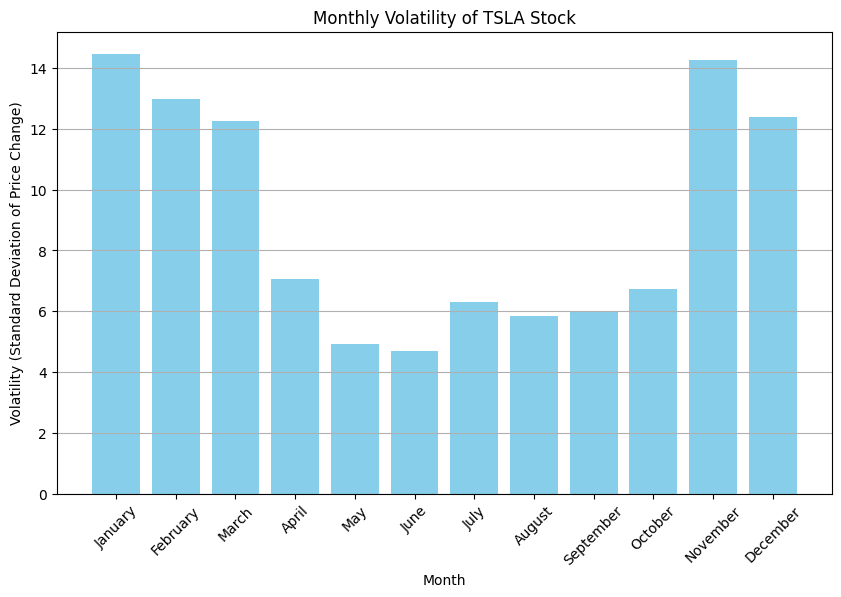

In [275]:
# Question 2 - Figure out which months are most volatile for TSLA stock and identify seasonal patterns?
print("Question 2 - Figure out which months are most volatile for TSLA stock and identify seasonal patterns?")

# date conversion
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

# calculate daily price change and add it as a new column
df['Price Change'] = df['Close'] - df['Open']

# calculate volatility with standard deviation of price change for each month
monthly_volatility = df.groupby('Month')['Price Change'].std().sort_values(ascending=False)
monthly_volatility = monthly_volatility.reset_index()
monthly_volatility.columns = ['Month', 'Volatility']

# display the monthly volatility
display(monthly_volatility)


# analyze the data and print insights
print("-" * 80)
print("Monthly Volatility Analysis:")
print()
print("-" * 80)
print("Which month is the most volatile on average?")
most_volatile_month = monthly_volatility.iloc[0]
print(f"The most volatile month is {most_volatile_month['Month']} with an average price change volatility of {most_volatile_month['Volatility']:.2f}")
print()
print("-" * 80)
print("Which month is the most stable on average?")
most_stable_month = monthly_volatility.iloc[-1]
print(f"The most stable month is {most_stable_month['Month']} with an average price change volatility of {most_stable_month['Volatility']:.2f}")
print()
print("-" * 80)
print("Are there any seasonal patterns in volatility?")
spring_months = ['March', 'April', 'May']
summer_months = ['June', 'July', 'August']
fall_months = ['September', 'October', 'November']
winter_months = ['December', 'January', 'February']
seasonal_volatility = {
    'Spring': monthly_volatility[monthly_volatility['Month'].isin(spring_months)]['Volatility'].mean(),
    'Summer': monthly_volatility[monthly_volatility['Month'].isin(summer_months)]['Volatility'].mean(),
    'Fall': monthly_volatility[monthly_volatility['Month'].isin(fall_months)]['Volatility'].mean(),
    'Winter': monthly_volatility[monthly_volatility['Month'].isin(winter_months)]['Volatility'].mean()
}
for season, volatility in seasonal_volatility.items():
    print(f"{season}: Average Volatility = {volatility:.2f}")
print()



# visualize the monthly volatility
print("-" * 80)
print("Visualizing Monthly Volatility:")
monthly_volatility['Month'] = pd.Categorical(monthly_volatility['Month'], categories=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)
monthly_volatility = monthly_volatility.sort_values('Month')
display(monthly_volatility)
plt.figure(figsize=(10, 6))
plt.bar(monthly_volatility['Month'], monthly_volatility['Volatility'], color='skyblue')
plt.title('Monthly Volatility of TSLA Stock')
plt.xlabel('Month')
plt.ylabel('Volatility (Standard Deviation of Price Change)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# print summary statements
def print_summary_statements_volatility():
    print("-" * 80)
    print("Question 2: Figure out which months are most volatile for TSLA stock and identify seasonal patterns?")
    print("-" * 80)
    print("1. The most volatile month is {} with an average price change volatility of {:.2f}.".format(most_volatile_month['Month'], most_volatile_month['Volatility']))
    print("2. The most stable month is {} with an average price change volatility of {:.2f}.".format(most_stable_month['Month'], most_stable_month['Volatility']))
    colored_print("This analysis indicates that there are indeed seasonal patterns in volatility, with certain months showing higher average price change \n volatility than others. Such as the winter months tend to have higher volatility compared to the summer months, which may suggest that\n market conditions or company events during those times contribute to increased price fluctuations.", Colors.GREEN )

## Question 3: Yearly Performance Analysis

**Task:** Analyze how TSLA's performance has varied year-over-year and create compelling visualizations.

**Skills demonstrated:**
- **DATA CONVERSION**: Extract years from dates
- **FILTERING**: Get data for specific years
- **AGGREGATION**: Calculate annual statistics
- **VISUALIZATION**: Create professional charts

**Questions to answer and visualize:**
- Which year had the best/worst performance?
- What was TSLA's average annual return?
- what is the overall annual return trend over the years?
- dispaly a bar chart of annual returns by year.

Question 3 - how has TSLA's performance varied year-by-year?


,Year,Start Price,End Price,Annual Return %
0,2010,3.80$,5.33$,40.16%
1,2011,5.37$,5.71$,6.41%
2,2012,5.79$,6.77$,17.04%
3,2013,7.00$,30.09$,329.80%
4,2014,29.96$,44.48$,48.47%
5,2015,44.57$,48.00$,7.69%
6,2016,46.14$,42.74$,-7.38%
7,2017,42.97$,62.27$,44.91%
8,2018,62.40$,66.56$,6.67%
9,2019,61.22$,83.67$,36.66%


--------------------------------------------------------------------------------
Year-by-Year Performance Analysis:

--------------------------------------------------------------------------------
Which year had the highest annual return?
The best performing year was 2020 with an annual return of 731.18%.

--------------------------------------------------------------------------------
Which year had the lowest annual return?
The worst performing year was 2022 with an annual return of -11.66%.

--------------------------------------------------------------------------------
What is the overall average annual return across all years?
The overall average annual return across all years is: 99.76%
--------------------------------------------------------------------------------
Visualizing Year-by-Year Performance:


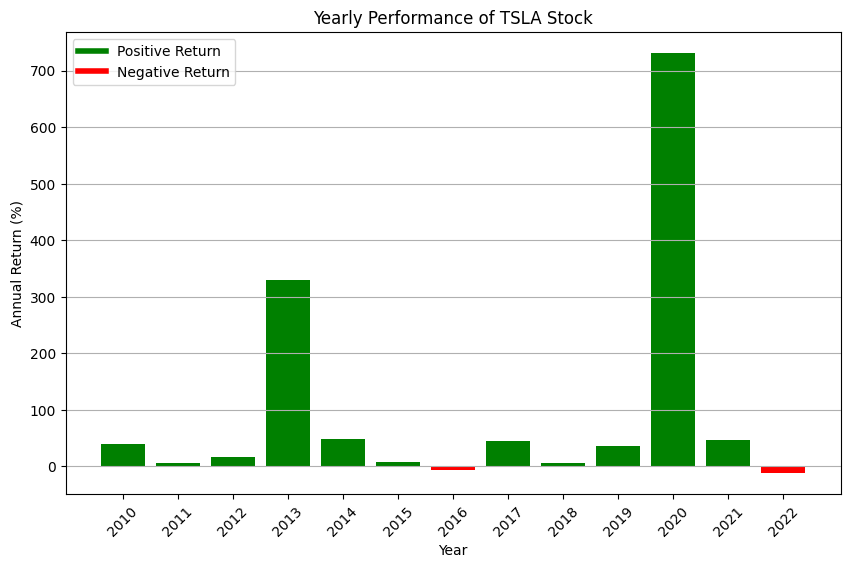

In [276]:
# Question 3 - how has TSLA's performance varied year-by-year?
print("Question 3 - how has TSLA's performance varied year-by-year?")

# extract year from date
df['Year'] = df['Date'].dt.year

# years in ascending order
years = sorted(df['Year'].unique())

# for each year get the starting price, ending price, and calculate the annual return
annual_performance = []
for year in years:
    yearly_data = df[df['Year'] == year]
    start_price = yearly_data.iloc[0]['Open']
    end_price = yearly_data.iloc[-1]['Close']
    annual_return = (((end_price - start_price) / start_price) * 100)
    annual_performance.append({'Year': year, 'Start Price': f"{start_price:.2f}$", 'End Price': f"{end_price:.2f}$", 'Annual Return %': f"{annual_return:.2f}%"})

# display the annual performance in a readable format
annual_performance_df = pd.DataFrame(annual_performance)
display(annual_performance_df)

# analyze the data and print insights
print("-" * 80)
print("Year-by-Year Performance Analysis:")
print()
print("-" * 80)
print("Which year had the highest annual return?")
best_year = annual_performance_df.iloc[annual_performance_df['Annual Return %'].str.rstrip('%').astype(float).idxmax()]
print(f"The best performing year was {best_year['Year']} with an annual return of {best_year['Annual Return %']}.")
print()
print("-" * 80)
print("Which year had the lowest annual return?")
worst_year = annual_performance_df.iloc[annual_performance_df['Annual Return %'].str.rstrip('%').astype(float).idxmin()]
print(f"The worst performing year was {worst_year['Year']} with an annual return of {worst_year['Annual Return %']}.")
print()
print("-" * 80)
print("What is the overall average annual return across all years?")
average_annual_return = annual_performance_df['Annual Return %'].str.rstrip('%').astype(float).mean()
print(f"The overall average annual return across all years is: {average_annual_return:.2f}%")

# visualize the annual performance
print("-" * 80)
print("Visualizing Year-by-Year Performance:")
plt.figure(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in annual_performance_df['Annual Return %'].str.rstrip('%').astype(float)]
plt.bar(annual_performance_df['Year'], annual_performance_df['Annual Return %'].str.rstrip('%').astype(float), color=colors)
plt.title('Yearly Performance of TSLA Stock')
plt.xlabel('Year')
plt.ylabel('Annual Return (%)')
plt.xticks(annual_performance_df['Year'], rotation=45)
plt.grid(axis='y')
plt.legend(handles=[plt.Line2D([0], [0], color='green', lw=4), plt.Line2D([0], [0], color='red', lw=4)], labels=['Positive Return', 'Negative Return'])
plt.show()


# print summary statements
def print_summary_statements_annual_performance():
    print("-" * 80)
    print("Question 3: how has TSLA's performance varied year-by-year?")
    print("-" * 80)
    print("1. The best performing year was {} with an annual return of {}.".format(best_year['Year'], best_year['Annual Return %']))
    print("2. The worst performing year was {} with an annual return of {}.".format(worst_year['Year'], worst_year['Annual Return %']))
    print("3. The overall average annual return across all years is: {:.2f}%.".format(average_annual_return))
    colored_print(" This analysis of the annual performance shows that even with the fluctuations, TSLA has experienced significant growth over the years.\n The average annual return is {:.2f}%.".format(average_annual_return), Colors.GREEN)

In [277]:
# 🎉 TSLA Data Analysis Summary 🎉

colored_print("TSLA Data Analysis Summary", Colors.GREEN, Colors.BOLD)
print()

print("Key Findings:")
print_summary_statements_volume()
print_summary_statements_volatility() 
print_summary_statements_annual_performance()
print()

TSLA Data Analysis Summary

Key Findings:
--------------------------------------------------------------------------------
Question 1: Find the top 10 days with the highest trading volume and analyze what happened to prices on those days?
--------------------------------------------------------------------------------
1. The highest volume trading day was on Feb 4, 2020 with a volume of 304,694,000 and a price change of 0.82 (0.46%).
2. The lowest volume trading day among the top 10 was on May 1, 2020 with a volume of 162,659,000 and a price change of -10.74 (-7.11%).
This indicates that high volume days can lead to significant price changes,
 but the direction of the change (increase or decrease) is not consistent across all high volume days.
--------------------------------------------------------------------------------
Question 2: Figure out which months are most volatile for TSLA stock and identify seasonal patterns?
----------------------------------------------------------------